In [24]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(54)

In [25]:
data = np.genfromtxt('GaltonFamilies.csv', delimiter=',', names=True, dtype=None, encoding='utf-8')

print(f"Columns: {data.dtype.names}")
print(f"Total rows: {len(data)}\n")
for row in data[:5]:
    print(row)

Columns: ('rownames', 'family', 'father', 'mother', 'midparentHeight', 'children', 'childNum', 'gender', 'childHeight')
Total rows: 934

(1, '001', 78.5, 67.0, 75.43, 4, 1, 'male', 73.2)
(2, '001', 78.5, 67.0, 75.43, 4, 2, 'female', 69.2)
(3, '001', 78.5, 67.0, 75.43, 4, 3, 'female', 69.0)
(4, '001', 78.5, 67.0, 75.43, 4, 4, 'female', 69.0)
(5, '002', 75.5, 66.5, 73.66, 4, 1, 'male', 73.5)


In [26]:
families = data['family']

# keep the first occurrence of each family (mirrors drop_duplicates(subset='family'))
_, first_idx = np.unique(families, return_index=True)
first_idx = np.sort(first_idx)

fathers = data['father'][first_idx].astype(float)
children = data['childHeight'].astype(float)

print(f"Father heights: n = {len(fathers)}")
print(f"Child heights: n = {len(children)}")

Father heights: n = 205
Child heights: n = 934


In [27]:
X = np.concatenate([fathers, children])

print(f"\nPooled dataset: n = {len(X)}, range = [{X.min():.1f}, {X.max():.1f}] inches")


Pooled dataset: n = 1139, range = [56.0, 79.0] inches


In [28]:
def gaussian_pdf(x, mu, sigma):
    return (1.0 / np.sqrt(2 * np.pi * sigma)) * np.exp(-((x - mu) ** 2) / (2 * sigma))

In [29]:
def log_likelihood(X, mu1, mu2, var1, var2, pi1, pi2):
    mix = pi1 * gaussian_pdf(X, mu1, var1) + pi2 * gaussian_pdf(X, mu2, var2)
    return np.sum(np.log(mix))

In [30]:
def init_params(X, seed=54):
  rng = np.random.default_rng(seed)
  mu1, mu2 = rng.choice(X, size=2, replace=False)
  var1 = var2 = np.var(X)
  pi1 = pi2 = 0.5
  return mu1, mu2, var1, var2, pi1, pi2

In [31]:
def em_gmm(X, n_iters=15, seed=54):
    mu1, mu2, var1, var2, pi1, pi2 = init_params(X, seed)
    ll = log_likelihood(X, mu1, mu2, var1, var2, pi1, pi2)

    history = [{'iter': 0, 'mu1': mu1, 'mu2': mu2, 'var1': var1, 'var2': var2,
                'pi1': pi1, 'pi2': pi2, 'log_likelihood': ll}]

    for it in range(1, n_iters + 1):
        # E-STEP
        p1 = pi1 * gaussian_pdf(X, mu1, var1)
        p2 = pi2 * gaussian_pdf(X, mu2, var2)
        total = p1 + p2
        gamma1 = p1 / total
        gamma2 = p2 / total

        # M-STEP
        N1, N2 = gamma1.sum(), gamma2.sum()

        mu1 = np.sum(gamma1 * X) / N1
        mu2 = np.sum(gamma2 * X) / N2

        var1 = np.sum(gamma1 * (X - mu1) ** 2) / N1
        var2 = np.sum(gamma2 * (X - mu2) ** 2) / N2

        pi1 = N1 / len(X)
        pi2 = N2 / len(X)

        ll = log_likelihood(X, mu1, mu2, var1, var2, pi1, pi2)
        history.append({'iter': it, 'mu1': mu1, 'mu2': mu2, 'var1': var1, 'var2': var2,
                         'pi1': pi1, 'pi2': pi2, 'log_likelihood': ll})

    return mu1, mu2, var1, var2, pi1, pi2, history


mu1, mu2, var1, var2, pi1, pi2, history = em_gmm(X, n_iters=15)

if mu1 > mu2:
    mu1, mu2 = mu2, mu1
    var1, var2 = var2, var1
    pi1, pi2 = pi2, pi1

print("Converged parameters:")
print(f"  mu1 (Children) = {mu1:.3f}   var1 = {var1:.3f}   pi1 = {pi1:.3f}")
print(f"  mu2 (Fathers)  = {mu2:.3f}   var2 = {var2:.3f}   pi2 = {pi2:.3f}")
print(f"  final log-likelihood = {history[-1]['log_likelihood']:.3f}")

Converged parameters:
  mu1 (Children) = 66.402   var1 = 11.528   pi1 = 0.814
  mu2 (Fathers)  = 70.750   var2 = 2.574   pi2 = 0.186
  final log-likelihood = -3050.601


In [32]:
iteration_labels = ['0 (Initialization)', '1', '2']
subset = history[:3]

col_names = ['Iteration', 'mu1 (Children)', 'mu2 (Fathers)', 'sigma1^2', 'sigma2^2', 'pi1', 'pi2', 'Log-Likelihood']
widths = [20, 16, 16, 12, 12, 10, 10, 16]

header_line = "".join(f"{name:<{w}}" for name, w in zip(col_names, widths))
print(header_line)
print("-" * len(header_line))

for label, r in zip(iteration_labels, subset):
    values = [label, r['mu1'], r['mu2'], r['var1'], r['var2'], r['pi1'], r['pi2'], r['log_likelihood']]
    line = f"{values[0]:<{widths[0]}}"
    for v, w in zip(values[1:], widths[1:]):
        line += f"{v:<{w}.4f}"
    print(line)

Iteration           mu1 (Children)  mu2 (Fathers)   sigma1^2    sigma2^2    pi1       pi2       Log-Likelihood  
----------------------------------------------------------------------------------------------------------------
0 (Initialization)  66.7000         76.0000         12.7241     12.7241     0.5000    0.5000    -3548.8773      
1                   66.3330         71.3715         9.9689      4.8493      0.8262    0.1738    -3060.2359      
2                   66.3498         71.1605         10.4464     4.1943      0.8215    0.1785    -3055.9935      


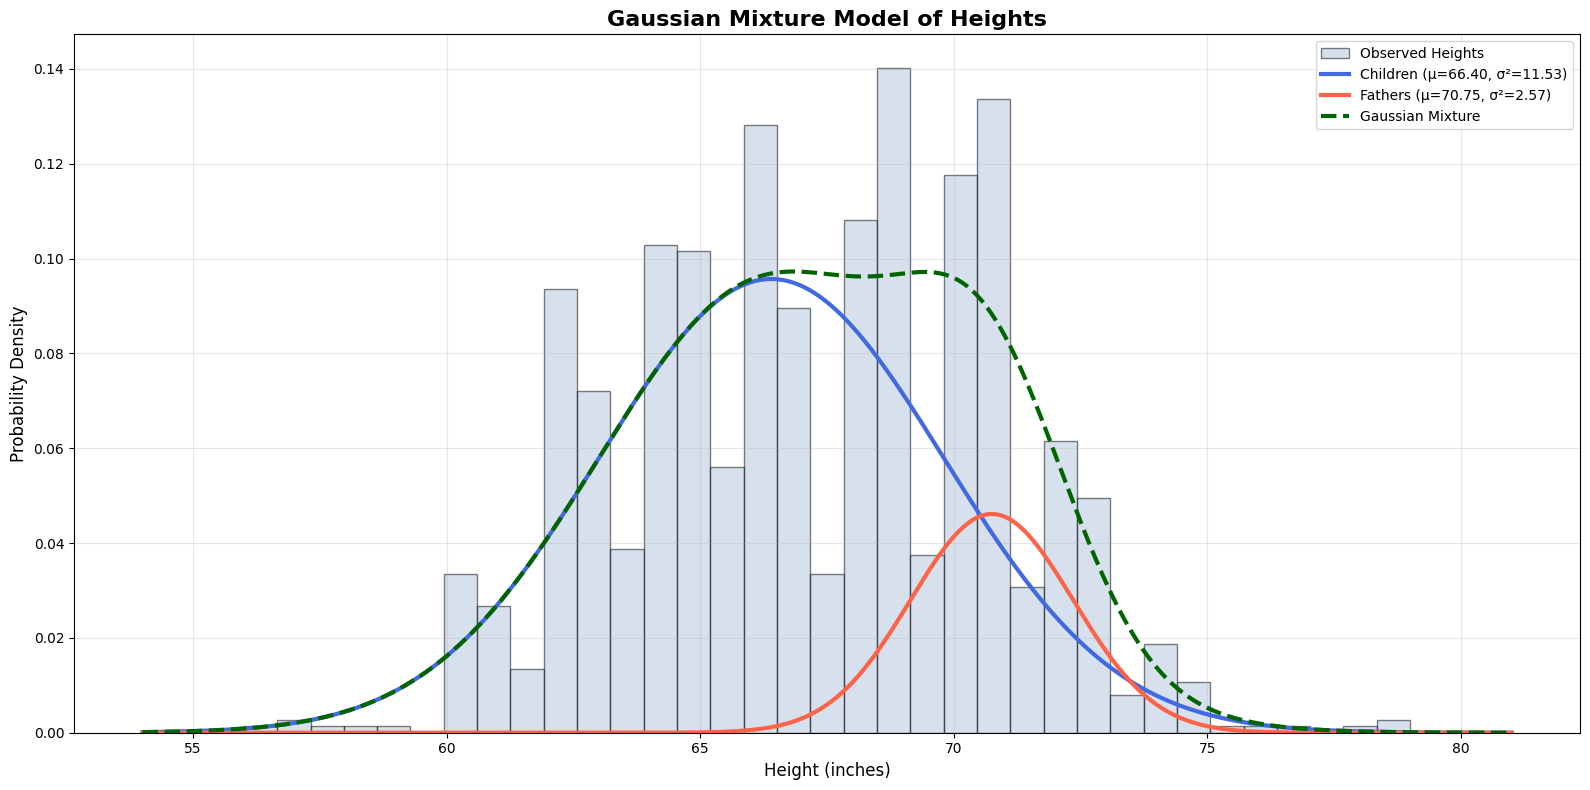

In [33]:
# Create x-axis values
x_grid = np.linspace(X.min() - 2, X.max() + 2, 600)


pdf1 = pi1 * gaussian_pdf(x_grid, mu1, var1)
pdf2 = pi2 * gaussian_pdf(x_grid, mu2, var2)
pdf_mix = pdf1 + pdf2


plt.figure(figsize=(16, 8))


plt.hist(
    X,
    bins=35,
    density=True,
    color='lightsteelblue',
    edgecolor='black',
    alpha=0.5,
    label='Observed Heights'
)


plt.plot(
    x_grid,
    pdf1,
    color='royalblue',
    linewidth=3,
    label=f'Children (μ={mu1:.2f}, σ²={var1:.2f})'
)

plt.plot(
    x_grid,
    pdf2,
    color='tomato',
    linewidth=3,
    label=f'Fathers (μ={mu2:.2f}, σ²={var2:.2f})'
)

plt.plot(
    x_grid,
    pdf_mix,
    color='darkgreen',
    linewidth=3,
    linestyle='--',
    label='Gaussian Mixture'
)

plt.title("Gaussian Mixture Model of Heights", fontsize=16, fontweight='bold')
plt.xlabel("Height (inches)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

plt.grid(alpha=0.3)


plt.legend(frameon=True)

plt.tight_layout()
plt.show()


In [34]:
def classify_height(x_new, mu1, mu2, var1, var2, pi1, pi2):
    p1 = pi1 * gaussian_pdf(x_new, mu1, var1)
    p2 = pi2 * gaussian_pdf(x_new, mu2, var2)

    total = p1 + p2

    post_child = p1 / total
    post_father = p2 / total

    return post_child, post_father


test_height = 72

post_child, post_father = classify_height(
 test_height, mu1, mu2, var1, var2, pi1, pi2
)

print(f"Test height: {test_height} inches\n")
print(f"P(Child  | x = {test_height}) = {post_child:.4f}")
print(f"P(Father | x = {test_height}) = {post_father:.4f}")

prediction = "CHILD" if post_child > post_father else "FATHER"
print(f"\nPredicted class: {prediction}")

Test height: 72 inches

P(Child  | x = 72) = 0.4192
P(Father | x = 72) = 0.5808

Predicted class: FATHER
